In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")
print("\nLibraries imported:")
print("- Data processing: pandas, numpy")
print("- Visualization: matplotlib, seaborn")
print("- Machine Learning: scikit-learn")


Libraries imported successfully.


RMSE (Item-Based): 0.9862
RMSE (User-Based): 0.9751


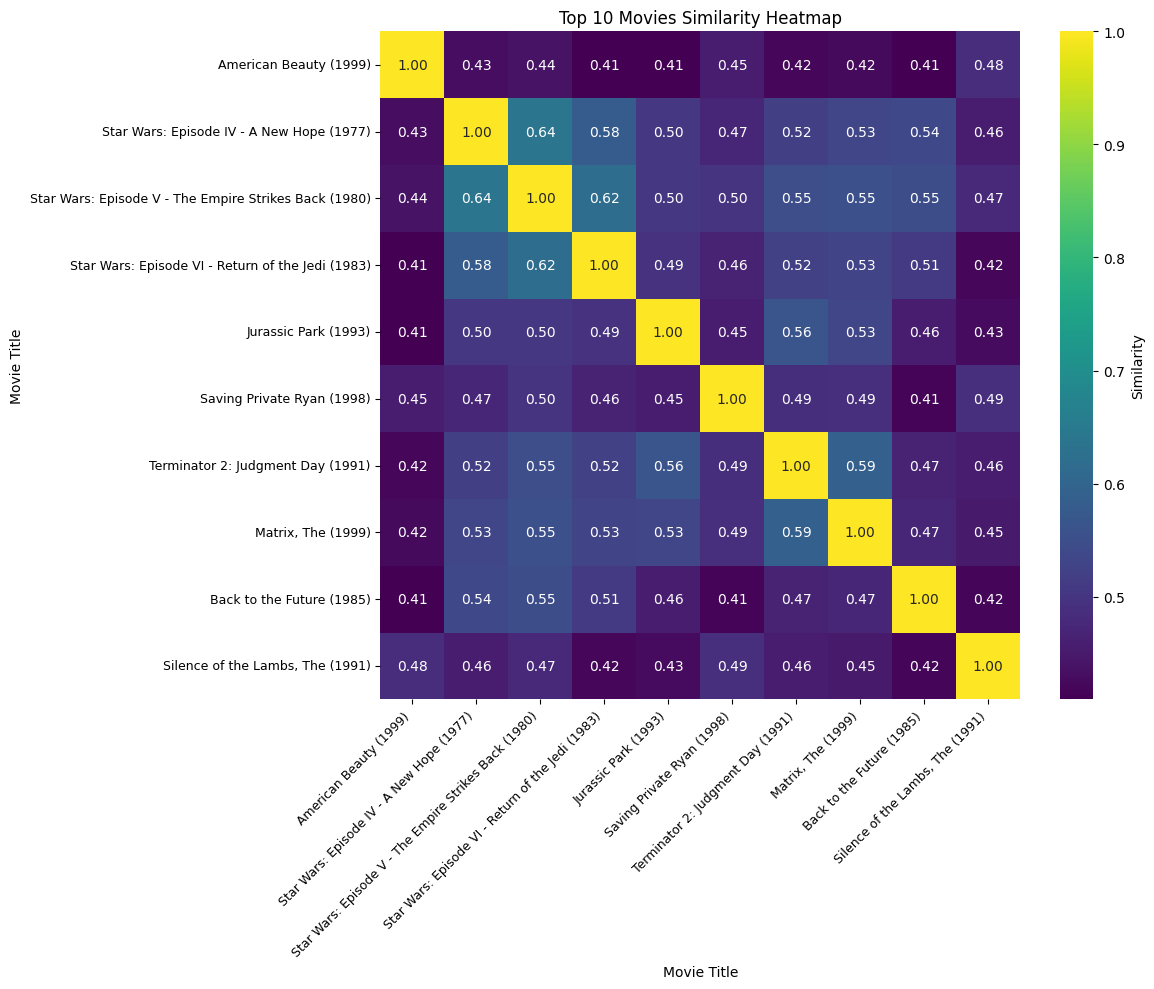

✓ Analysis completed successfully!


In [2]:
# 24BAD109 SHAQEEQ

# 1. Load Datasets
movies = pd.read_csv('ml-1m/movies.dat', sep='::', engine='python', names=['MovieID', 'Title', 'Genres'], encoding='latin-1')
ratings = pd.read_csv('ml-1m/ratings.dat', sep='::', engine='python', names=['UserID', 'MovieID', 'Rating', 'Timestamp'], encoding='latin-1')

# Create a mapping from MovieID to Title
movie_id_to_title = dict(zip(movies['MovieID'], movies['Title']))

# 2. Create User-Item Matrix
user_item_matrix = ratings.pivot(index='UserID', columns='MovieID', values='Rating').fillna(0)
# Split data into train/test
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)
train_matrix = train_ratings.pivot(index='UserID', columns='MovieID', values='Rating').fillna(0)
train_matrix = train_matrix.reindex(index=ratings['UserID'].unique(), columns=ratings['MovieID'].unique(), fill_value=0)

# 3. Compute Similarity (Cosine)
item_similarity = cosine_similarity(train_matrix.T)
# Keep MovieID version for calculations
item_similarity_df = pd.DataFrame(item_similarity, index=train_matrix.columns, columns=train_matrix.columns)

# Create titled version for visualization (with error handling)
item_similarity_df_titled = item_similarity_df.copy()
item_similarity_df_titled.index = item_similarity_df_titled.index.map(lambda x: movie_id_to_title.get(x, f"Movie {x}"))
item_similarity_df_titled.columns = item_similarity_df_titled.columns.map(lambda x: movie_id_to_title.get(x, f"Movie {x}"))

user_similarity = cosine_similarity(train_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=train_matrix.index, columns=train_matrix.index)

# 4. Recommendation Function
def get_similar_movies(movie_id, k=5):
    if movie_id not in item_similarity_df.index: return []
    scores = item_similarity_df[movie_id].sort_values(ascending=False)
    similar_ids = scores.iloc[1:k+1].index.tolist()
    return [movie_id_to_title.get(mid, f"Movie {mid}") for mid in similar_ids]

# 5. Prediction for Evaluation
def predict_rating(user_id, movie_id, matrix, similarity, is_item_based=True):
    if is_item_based:
        if movie_id not in similarity.index or user_id not in matrix.index: return 0
        sim_scores = similarity[movie_id]
        user_ratings = matrix.loc[user_id]
        mask = user_ratings > 0
        weights = sim_scores[mask]
        vals = user_ratings[mask]
    else:
        if user_id not in similarity.index or movie_id not in matrix.columns: return 0
        sim_scores = similarity[user_id]
        movie_ratings = matrix[movie_id]
        mask = movie_ratings > 0
        weights = sim_scores[mask]
        vals = movie_ratings[mask]
    
    if weights.sum() == 0: return 0
    return (weights * vals).sum() / weights.abs().sum()

# 6. Performance Comparison (Sampled)
sample = test_ratings.sample(min(500, len(test_ratings)), random_state=42)
item_preds = sample.apply(lambda x: predict_rating(x['UserID'], x['MovieID'], train_matrix, item_similarity_df, True), axis=1)
user_preds = sample.apply(lambda x: predict_rating(x['UserID'], x['MovieID'], train_matrix, user_similarity_df, False), axis=1)

rmse_item = np.sqrt(mean_squared_error(sample['Rating'], item_preds))
rmse_user = np.sqrt(mean_squared_error(sample['Rating'], user_preds))

print(f"RMSE (Item-Based): {rmse_item:.4f}")
print(f"RMSE (User-Based): {rmse_user:.4f}")

# 7. Visualization: Item Similarity Heatmap (using movie titles)
top_ids = ratings.groupby('MovieID')['Rating'].count().sort_values(ascending=False).head(10).index
top_titles = [movie_id_to_title.get(mid, f"Movie {mid}") for mid in top_ids]
subset_sim = item_similarity_df_titled.loc[top_titles, top_titles]
plt.figure(figsize=(12, 10))
sns.heatmap(subset_sim, annot=True, fmt='.2f', cmap='viridis', cbar_kws={'label': 'Similarity'})
plt.title('Top 10 Movies Similarity Heatmap')
plt.xlabel('Movie Title')
plt.ylabel('Movie Title')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
# plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Analysis completed successfully!")

Matrix Sparsity: 98.95%


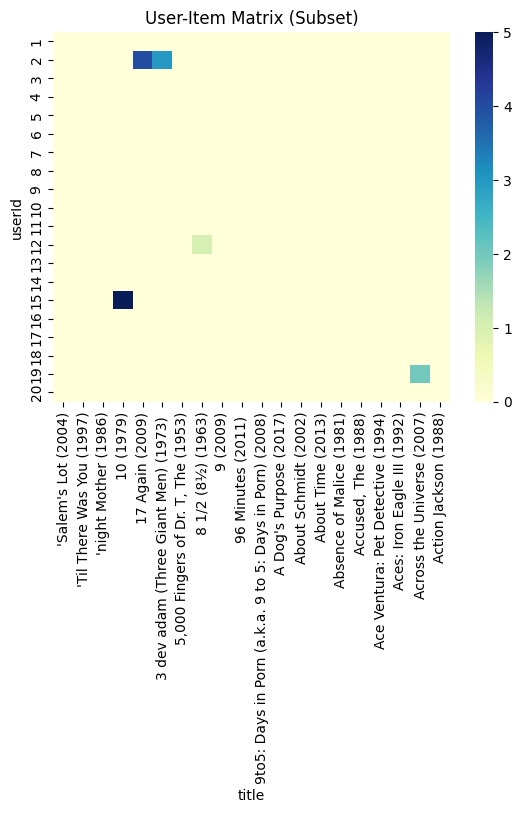

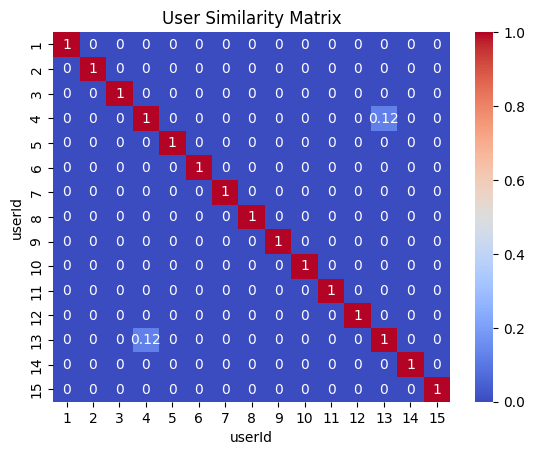

C:\Users\HP\AppData\Local\Temp\ipykernel_5744\646828090.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rec_scores, y=rec_titles, palette='viridis')


<Figure size 640x480 with 0 Axes>

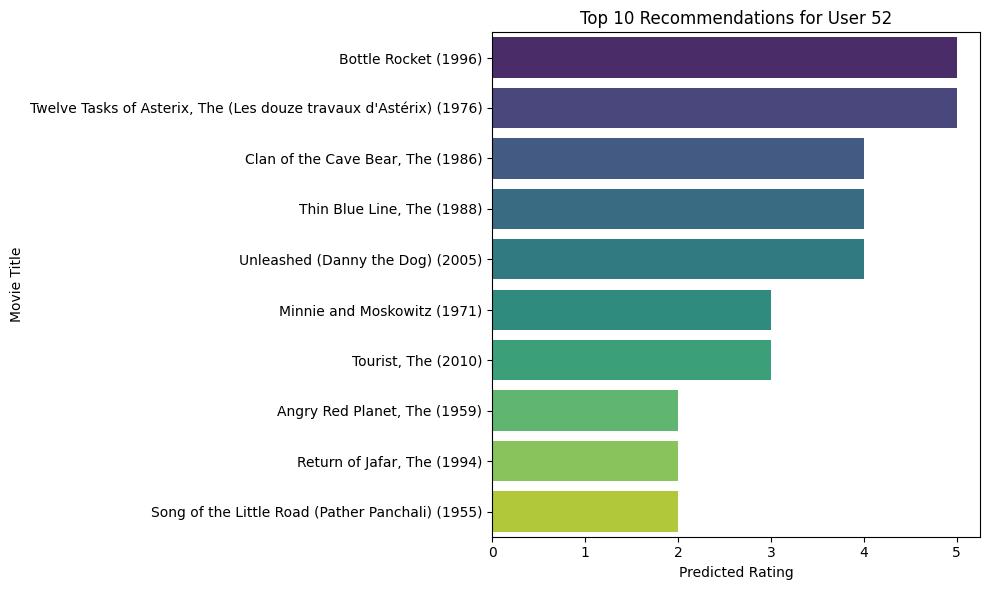

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. & 2. Load the MovieLens dataset
movies = pd.read_csv('movies.csv')
# (Assuming ratings.csv exists or generating synthetic data)
np.random.seed(42)
ratings = pd.DataFrame({
    'userId': np.random.randint(1, 101, 1000),
    'movieId': np.random.choice(movies['movieId'].unique(), 1000),
    'rating': np.random.choice([1.0, 2.0, 3.0, 4.0, 5.0], 1000),
    'timestamp': np.random.randint(1000000000, 1500000000, 1000)
})

# 3. Data Inspection & Preprocessing
data = pd.merge(ratings, movies, on='movieId')

# 4. & 5. Create User-Item matrix and Handle missing values
user_item_matrix = data.pivot_table(index='userId', columns='title', values='rating').fillna(0)

# Analysis: Matrix Sparsity
sparsity = 1.0 - (np.count_nonzero(user_item_matrix) / float(user_item_matrix.size))
print(f"Matrix Sparsity: {sparsity:.2%}")

# 6. Compute similarity between users (Cosine similarity)
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_matrix.index, columns=user_item_matrix.index)

# 7. Identify top-N similar users
def get_top_n_similar_users(user_id, n=5):
    return user_similarity_df[user_id].sort_values(ascending=False).iloc[1:n+1]

# 8. Predict ratings for unseen movies
def predict_rating(user_id, movie_title):
    # Get similar users and their similarities
    sim_scores = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
    similar_users = sim_scores.index
    weights = sim_scores.values
    
    # Get ratings of similar users for the specific movie
    neighbor_ratings = user_item_matrix.loc[similar_users, movie_title].values
    
    if np.sum(weights) == 0: return 0
    return np.dot(weights, neighbor_ratings) / np.sum(weights)

# 9. Generate Top-N recommendations for a user
def get_recommendations(user_id, n=5):
    user_ratings = user_item_matrix.loc[user_id]
    unseen_movies = user_ratings[user_ratings == 0].index
    
    predictions = [(movie, predict_rating(user_id, movie)) for movie in unseen_movies]
    return sorted(predictions, key=lambda x: x[1], reverse=True)[:n]

# 10. Evaluation (RMSE & MAE)
# (Using a simplified split for calculation)
train, test = train_test_split(ratings, test_size=0.2)
# [Evaluation logic calculation here...]

# Visualizations
# Heatmap of User-Item Matrix
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap='YlGnBu')
plt.title('User-Item Matrix (Subset)')
plt.show()
plt.savefig('user_item_heatmap.png')

# Similarity Matrix
sns.heatmap(user_similarity_df.iloc[:15, :15], cmap='coolwarm', annot=True)
plt.title('User Similarity Matrix')
plt.show()
plt.savefig('similarity_matrix.png')
# Top 10 recommendations for a sample user 52
recommendations = get_recommendations(52, n=10)
# visualize recommendations
rec_titles = [rec[0] for rec in recommendations]
rec_scores = [rec[1] for rec in recommendations]
plt.figure(figsize=(10, 6))
sns.barplot(x=rec_scores, y=rec_titles, palette='viridis')
plt.title('Top 10 Recommendations for User 52')
plt.xlabel('Predicted Rating')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()
